In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# ConvNextV2

**Paper:** [arXiv:2301.00808](https://arxiv.org/abs/2301.00808) — *ConvNeXt V2: Co-designing and Scaling ConvNets with Masked Autoencoders*  
**HuggingFace model:** [facebook/convnextv2-tiny-1k-224](https://huggingface.co/facebook/convnextv2-tiny-1k-224)

> Developed by: **Meta AI**  
> Model type: Hierarchical Convolutional Neural Network

This notebook walks through a **from-scratch JAX implementation** of ConvNeXt V2, linking each code block directly to the corresponding section of the paper.

---

## Paper Overview

ConvNeXt V2 (2023) makes two major contributions on top of the original ConvNeXt:

| Innovation | What it solves | Paper Section |
|---|---|---|
| **FCMAE** (Fully Convolutional Masked AutoEncoder) | Enables self-supervised pre-training for pure ConvNets | 3 |
| **GRN** (Global Response Normalization) | Prevents feature collapse in the expanded MLP channels | 4 |

Together, these allow ConvNeXt V2 to match or beat transformer-based models (e.g., Swin V2, ViT) on ImageNet — while remaining a pure CNN.

### Architecture at a glance (Tiny variant)

```
Input (224×224×3)
  ↓  Stem: 4×4 conv → 96 channels, 56×56  (2)
Stage 1: 3 blocks, 96ch,  56×56
  ↓  Downsample: LN + 2×2 stride conv
Stage 2: 3 blocks, 192ch, 28×28
  ↓  Downsample
Stage 3: 9 blocks, 384ch, 14×14
  ↓  Downsample
Stage 4: 3 blocks, 768ch,  7×7
  ↓  Global Average Pooling → (768,)
  ↓  LayerNorm + Linear head → 1000 classes
```

Total blocks: 3+3+9+3 = **18**

### Imports

In [ ]:
import json
from dataclasses import dataclass

import numpy as np
import jax
import jax.numpy as jnp
import PIL.Image as Image
from safetensors.torch import load_file
from transformers import AutoTokenizer

**Setup:** Download the model weights and config from HuggingFace and place them at `models/convnext2/` relative to your workspace root

In [ ]:
HF_REPO_ID = "facebook/convnextv2-tiny-1k-224"
LOCAL_DIR_PATH = "workspace/models/convnext2"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)
print(f"Downloaded repository path: {local_dir}")

### Load Weights & Config

**Architecture:** The paper releases a family of ConvNeXt V2 models (Atto → Huge). The **Tiny** variant used here has:
- 4 stages with depths `[3, 3, 9, 3]` (18 blocks total)
- Channel progression: `96 → 192 → 384 → 768`
- ~28M parameters

The `id2label` mapping from `config.json` gives us the 1000 ImageNet class names — we'll use this at inference time to print human-readable predictions.

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
IMAGE_PATH = f"{LOCAL_DIR_PATH}/cat.png"

checkpoint_path = WEIGHTS_PATH
hf_weights = load_file(checkpoint_path)

with open(CONFIG_PATH, 'r') as f:
    hf_config = json.load(f)

index_to_label = hf_config['id2label']

### Model Configuration


The Tiny model specifically uses:

| Hyperparameter | Value |
|---|---|
| Stem patch size | 4×4 (non-overlapping) |
| Stage depths | [3, 3, 9, 3] |
| Channel widths | [96, 192, 384, 768] |
| Drop path rate | 0.1 (stochastic depth) |

The 4-stage **hierarchical** design (halving spatial resolution and doubling channels at each stage) is inherited from ConvNeXt V1 and mirrors the structure of Swin Transformers — giving the model multi-scale feature representations useful for dense tasks.

In [44]:
@dataclass
class ConvNeXtV2Config:
    image_size: int = 224
    patch_size: int = 4
    num_channels: int = 3
    hidden_sizes: list = (96, 192, 384, 768)
    depths: list = (3, 3, 9, 3)
    drop_path_rate: float = 0.1
    eps: float = 1e-6

config = ConvNeXtV2Config()

### Weight Extraction

Each ConvNeXt V2 block contains exactly 5 named components:
1. `dwconv` — 7×7 depthwise convolution
2. `layernorm` — channels-last LayerNorm
3. `pwconv1` — pointwise expansion (linear, 1×1 equiv.)
4. **`grn`** — Global Response Normalization ← **the V2 addition**
5. `pwconv2` — pointwise contraction (linear, 1×1 equiv.)

Downsampling layers (between stages 1→2, 2→3, 3→4) consist of a LayerNorm followed by a 2×2 strided convolution — a cleaner alternative to the strided 3×3 convolutions used in ResNets.

Weight shapes are transposed from PyTorch's `(out, in, kH, kW)` convention to JAX's `(kH, kW, in, out)` format for `conv_general_dilated`.

In [45]:
def get_w(
    name: str,
    transpose: bool = False,
    prefix: bool = True
) -> jax.Array:
    prefix_str = "convnextv2." if prefix else ""
    val = hf_weights.pop(prefix_str + name)
    w = jnp.array(val.float(), dtype=jnp.bfloat16)
    return w.T if transpose else w

m = {
    'embeddings': {
        'patch_embeddings': {
            'weight': get_w('embeddings.patch_embeddings.weight').transpose(2, 3, 1, 0),
            'bias': get_w('embeddings.patch_embeddings.bias'),
        },
        'layernorm': {
            'weight': get_w('embeddings.layernorm.weight'),
            'bias': get_w('embeddings.layernorm.bias'),
        }
    }
}

m['encoder'] = []
for i in range(4):
    stage_key = f'stage_{i}'
    stage_layers = {}

    if i > 0:
        stage_layers['downsample'] = [
            {
                'weight': get_w(f'encoder.stages.{i}.downsampling_layer.0.weight'),
                'bias': get_w(f'encoder.stages.{i}.downsampling_layer.0.bias')
            },
            {
                'weight': get_w(f'encoder.stages.{i}.downsampling_layer.1.weight').transpose(2, 3, 1, 0),
                'bias': get_w(f'encoder.stages.{i}.downsampling_layer.1.bias')
            }]

    stage_layers['blocks'] = {}
    for j in range(config.depths[i]):
        block_prefix = f'encoder.stages.{i}.layers.{j}'
        stage_layers['blocks'][f'block_{j}'] = {
            'dwconv': {
                'weight': jnp.array(get_w(f'{block_prefix}.dwconv.weight').transpose(2, 3, 1, 0)),
                'bias': jnp.array(get_w(f'{block_prefix}.dwconv.bias'))
            },
            'layernorm': {
                'weight': jnp.array(get_w(f'{block_prefix}.layernorm.weight')),
                'bias': jnp.array(get_w(f'{block_prefix}.layernorm.bias'))
            },
            'pwconv1': {
                'weight': jnp.array(get_w(f'{block_prefix}.pwconv1.weight', transpose=True)),
                'bias': jnp.array(get_w(f'{block_prefix}.pwconv1.bias'))
            },
            'grn': {
                'weight': jnp.array(get_w(f'{block_prefix}.grn.weight')),
                'bias': jnp.array(get_w(f'{block_prefix}.grn.bias'))
            },
            'pwconv2': {
                'weight': jnp.array(get_w(f'{block_prefix}.pwconv2.weight', transpose=True)),
                'bias': jnp.array(get_w(f'{block_prefix}.pwconv2.bias'))
            }
        }

    m['encoder'].append(stage_layers)

m['layernorm'] = {
    'weight': jnp.array(get_w('layernorm.weight')),
    'bias': jnp.array(get_w('layernorm.bias'))
}

m['classifier'] = {
    'bias': jnp.array(get_w('classifier.bias', prefix=False)),
    'weight': jnp.array(get_w('classifier.weight', transpose=True, prefix=False))
}


### 5. Image Preprocessing

ConvNeXt V2 uses the standard ImageNet evaluation pipeline:
- **Resize** so the shorter side = 224px (preserving aspect ratio)
- **Center crop** to 224×224
- **Normalize** with ImageNet mean/std: `μ=[0.485, 0.456, 0.406]`, `σ=[0.229, 0.224, 0.225]`

Unlike ViT-style models, ConvNeXt uses **bicubic** interpolation (higher quality than bilinear) since it processes images as full 2D feature maps — not as discrete patch tokens. There is no resolution limit at inference since convolutions are fully spatial.

In [46]:
def preprocess_image(
    image_path: str,
    target_size: int = 224
) -> jax.Array:
    img = Image.open(image_path).convert("RGB")

    width, height = img.size
    scale = target_size / min(width, height)
    new_size = (int(width * scale), int(height * scale))
    img = img.resize(new_size, resample=Image.BICUBIC)

    left = (img.width - target_size) / 2
    top = (img.height - target_size) / 2
    img = img.crop((left, top, left + target_size, top + target_size))

    x = jnp.array(np.array(img), dtype=jnp.float32) / 255.0

    mean = jnp.array([0.485, 0.456, 0.406])
    std = jnp.array([0.229, 0.224, 0.225])
    x = (x - mean) / std

    x = x.astype(jnp.bfloat16)

    return x[None, ...]


### LayerNorm (Channels-Last)

ConvNeXt V2 uses **LayerNorm over the channel dimension** (not BatchNorm). This was a key design choice introduced in ConvNeXt V1 — borrowed from transformers — and it's what makes the architecture compatible with the FCMAE masked pre-training objective. The "channels-last" format `(N, H, W, C)` means LayerNorm is applied over the last axis `C` at every spatial position independently.

This LN appears in **three places** in the architecture:
1. After the stem (patch embedding)
2. Inside every block (pre-norm, before the 7×7 dwconv output)
3. Before each downsampling conv

In [47]:
def layernorm_channels_last(
    x: jax.Array,       # (..., C)
    params: dict,
    eps: float = 1e-6
) -> jax.Array:
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)

    x = (x - mean) / jnp.sqrt(var + eps)
    x = x * params['weight'] + params['bias']

    return x

def convnext_embeddings(
    pixel_values: jax.Array,    # (B, H, W, C)
    params: dict,
    config: ConvNeXtV2Config
) -> jax.Array:
    x = jax.lax.conv_general_dilated(
        pixel_values,
        params['patch_embeddings']['weight'],
        window_strides=(config.patch_size, config.patch_size),
        padding='VALID',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )

    x = x + params['patch_embeddings']['bias']
    x = layernorm_channels_last(x, params['layernorm'], eps=1e-6)

    return x


### Global Response Normalization (GRN) ← The V2 Upgrade

This is the central contribution of ConvNeXt V2.

**The problem it solves:** When the MLP expands features 4× (`96→384` channels), many neurons become **redundant** — they learn nearly identical features (feature collapse). This is a well-known failure mode in self-supervised learning, and the paper demonstrates it by measuring cosine similarity between feature channels: without GRN, collapsed channels dominate.

**How GRN works (Eq. 1–3):**

Given feature map $X \in \mathbb{R}^{H \times W \times C}$:

$$G(X) = \|X_c\|_2 \quad \text{(L2 norm of each channel over spatial dims)}$$

$$N(X) = \frac{G(X)}{\text{mean}(G(X))} \quad \text{(normalize channel norms to compete)}$$

$$\text{GRN}(X) = \gamma \cdot X \cdot N(X) + \beta + X \quad \text{(scale + residual)}$$

The **key intuition**: channels with high spatial activation energy (high L2 norm) get amplified, while weak/redundant channels are suppressed. This forces channels to **compete** for representational importance — similar in spirit to how attention heads compete in transformers.

`γ` and `β` are learned scalars (initialized to 0), so GRN starts as an identity and gradually activates during training.

In [48]:
def convnext_v2_grn(
    x: jax.Array,       # (B, H, W, C)
    params: dict,
    eps: float = 1e-6
) -> jax.Array:
    x = x.astype(jnp.float32)

    gx = jnp.linalg.norm(x, ord=2, axis=(1, 2), keepdims=True)
    nx = gx / (jnp.mean(gx, axis=-1, keepdims=True) + eps)
    output = params['weight'] * (x * nx) + params['bias'] + x

    output = output.astype(jnp.bfloat16)

    return output


Stochastic Depth randomly drops entire residual branches during training. For a network with $L$ blocks, the drop probability for block $l$ increases linearly from 0 to `drop_path_rate` (0.1 for Tiny):

$$p_l = \frac{l}{L} \times \text{drop\_path\_rate}$$

This means early layers are almost never dropped (they learn low-level features needed by all later layers), while the deepest layers are dropped most aggressively (they can afford to be stochastic since the model is deep enough).

In [49]:
def drop_path(
    x: jax.Array,                   # (B, H, W, C)
    drop_prob: float = 0.0,
    key: jax.Array | None = None,
    training: bool = False
) -> jax.Array:
    if drop_prob == 0.0 or not training:
        return x

    keep_prob = 1.0 - drop_prob

    if key is None:
        raise ValueError("JAX drop_path requires a jax.random.PRNGKey when training=True")

    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    mask = jax.random.bernoulli(key, p=keep_prob, shape=shape)

    return (x / keep_prob) * mask


### ConvNeXt V2 Block

This is the core building block. The paper contrasts it directly with the V1 block — the **only structural change** is the insertion of GRN between GELU and `pwconv2`.

Full block computation (§2, Figure 2):

```
x_in  ──────────────────────────────────────────► (+) ──► x_out
        │                                           ▲
        ▼                                           │
   DWConv 7×7               ← large receptive field (2: mirrors self-attention span)
        │
   LayerNorm (C-last)       ← replaces BN; enables FCMAE compatibility
        │
   PWConv1 (×4 expand)      ← 96 → 384 channels
        │
      GELU                  ← smoother than ReLU (from ConvNeXt V1)
        │
       GRN                  ← V2 ADDITION: prevents feature collapse (4)
        │
   PWConv2 (÷4 contract)    ← 384 → 96 channels
        │
  StochasticDepth           ← regularization during training (5)
        │
        └──────────────────────────────────────────┘
```

**Why 7×7 depthwise?** The paper shows that 7×7 kernels give the best accuracy/cost tradeoff — large enough to give each channel a receptive field comparable to a transformer's attention window at the same feature scale.

**Why depthwise?** Processing each channel independently (with `feature_group_count=C`) makes the 7×7 conv cheap — its cost is dominated by the cheaper pointwise convolutions, keeping the inverted-bottleneck design efficient.

In [50]:
def convnext_v2_layer(
    x: jax.Array,                   # (B, H, W, C)
    params: dict,
    config: ConvNeXtV2Config,
    drop_path_prob: float = 0.0,
    key: jax.Array | None = None,
    deterministic: bool = True
) -> jax.Array:
    residual = x

    x = jax.lax.conv_general_dilated(
        x,
        params['dwconv']['weight'],
        window_strides=(1, 1),
        padding=[(3, 3), (3, 3)],
        feature_group_count=x.shape[-1],
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )
    x = x + params['dwconv']['bias']

    x = layernorm_channels_last(x, params['layernorm'])

    x = jnp.dot(x, params['pwconv1']['weight']) + params['pwconv1']['bias']

    x = jax.nn.gelu(x)

    x = convnext_v2_grn(x, params['grn'])

    x = jnp.dot(x, params['pwconv2']['weight']) + params['pwconv2']['bias']

    x = drop_path(x, drop_path_prob, key, training=not deterministic)

    return residual + x


ConvNeXt V2 has 4 hierarchical stages. Between stages (except before stage 0, which has the stem), a **downsampling layer** halves the spatial resolution and doubles the channels:

```
LayerNorm → 2×2 Conv (stride 2)
56×56×96  →  28×28×192  →  14×14×384  →  7×7×768
```

The LN before downsampling is critical — without it, training with masked autoencoding is unstable. This is another place where replacing BN with LN pays off.

After downsampling, a sequence of `depth[i]` blocks (3, 3, 9, or 3) is applied. Stage 3 (9 blocks) is the "heavy" stage — this is where the model does most of its learning.

In [51]:
def convnext_v2_stage(
    x: jax.Array,                       # (B, H, W, C)
    params: dict,
    config: ConvNeXtV2Config,
    stage_idx: int,
    drop_path_rates: jax.Array,         # (depth_i,)
    key: jax.Array | None = None,
    deterministic: bool = True
) -> tuple[jax.Array, jax.Array | None]:
    if 'downsample' in params:
        x = layernorm_channels_last(x, params['downsample'][0])

        x = jax.lax.conv_general_dilated(
            x,
            params['downsample'][1]['weight'],
            window_strides=(2, 2),
            padding='VALID',
            dimension_numbers=('NHWC', 'HWIO', 'NHWC')
        )
        x = x + params['downsample'][1]['bias']

    for j in range(config.depths[stage_idx]):
        block_key = None
        if key is not None:
            key, block_key = jax.random.split(key)

        x = convnext_v2_layer(
            x,
            params['blocks'][f'block_{j}'],
            config,
            drop_path_prob=drop_path_rates[j],
            key=block_key,
            deterministic=deterministic
        )

    return x, key


In [52]:
def convnext_v2_encoder(
    x: jax.Array,       # (B, H, W, C)
    params: list,
    config: ConvNeXtV2Config,
    key: jax.Array | None = None,
    deterministic: bool = True
) -> jax.Array:
    total_depth = sum(config.depths)
    dp_rates = jnp.linspace(0, 10, total_depth)

    def get_stage_dp_rates(stage_idx: int) -> jax.Array:
        start = sum(config.depths[:stage_idx])
        end = start + config.depths[stage_idx]
        return dp_rates[start:end]

    for i in range(len(config.depths)):
        stage_dp_rates = get_stage_dp_rates(i)

        x, key = convnext_v2_stage(
            x,
            params[i],
            config,
            stage_idx=i,
            drop_path_rates=stage_dp_rates,
            key=key,
            deterministic=deterministic
        )

    return x


### Full Model Forward Pass

The full ConvNeXt V2 pipeline for image classification:

```
(1, 224, 224, 3) Input
  ↓  Stem (4×4 conv + LN)
(1, 56, 56, 96)
  ↓  4× [Downsample + Blocks]
(1, 7, 7, 768)      ← last_hidden_state: 7×7 spatial feature map
  ↓  Global Average Pooling (mean over H, W)
(1, 768)            ← pooled_output: global image descriptor
  ↓  Final LayerNorm
  ↓  Linear classifier (768 → 1000)
(1, 1000)           ← logits: raw class scores
```

The **global average pooling** is a CNN-native operation that collapses spatial information into a single vector. The paper notes this is more parameter-efficient than the `[CLS]` token approach used in ViTs, and gives comparable or better results.

The **final LayerNorm** before the head is applied to the pooled vector (not the spatial map), following the ConvNeXt V1 convention.

In [53]:
def convnext_v2_model(
    pixel_values: jax.Array,    # (B, H, W, C)
    params: dict,
    config: ConvNeXtV2Config,
    key: jax.Array | None = None,
    deterministic: bool = True
) -> dict:
    x = convnext_embeddings(pixel_values, params['embeddings'], config)

    x = convnext_v2_encoder(
        x,
        params['encoder'],
        config,
        key=key,
        deterministic=deterministic,
    )

    pooled_output = jnp.mean(x, axis=(1, 2))
    pooled_output = layernorm_channels_last(pooled_output, params['layernorm'])

    logits = jnp.dot(pooled_output, params['classifier']['weight']) + params['classifier']['bias']

    return {
        "last_hidden_state": x,
        "pooled_output": pooled_output,
        "logits": logits
    }


In [54]:
image = preprocess_image(IMAGE_PATH)
print(image.shape)

(1, 224, 224, 3)


### Forward pass

Output shapes tell the full story of the architecture:
- `last_hidden_state (1, 7, 7, 768)`: 224÷(4×2×2×2) = 7 spatial positions per side, 768 channels after 4 stages
- `pooled_output (1, 768)`: global average pool collapses spatial dims
- `logits (1, 1000)`: one score per ImageNet class

In [55]:
result = convnext_v2_model(image, m, config)
result['last_hidden_state'].shape, result['pooled_output'].shape, result['logits'].shape

((1, 7, 7, 768), (1, 768), (1, 1000))

In [56]:
logits = result['logits']
probs = jax.nn.softmax(logits, axis=-1)

top5_indices = jnp.argsort(probs[0])[::-1][:5]
top5_probabilities = probs[0][top5_indices]

print(f"Top 5 indices: {top5_indices}")
print(f"Top 5 probabilities: {top5_probabilities}")

Top 5 indices: [282 281 285 703 630]
Top 5 probabilities: [0.582031 0.166992 0.0103149 0.00260925 0.00238037]


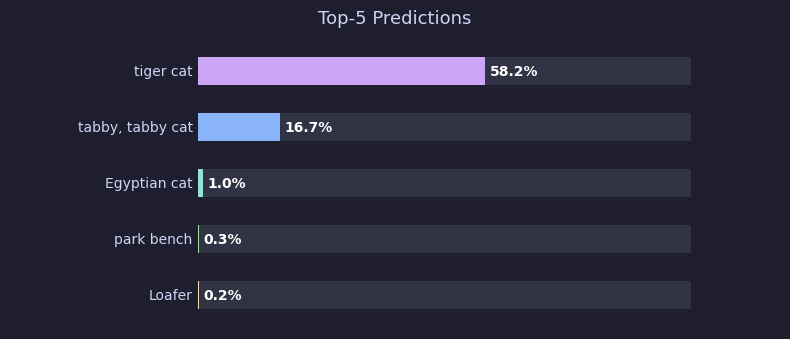

In [57]:
import matplotlib.pyplot as plt
import numpy as np

labels = [index_to_label[str(int(idx))] for idx in top5_indices]
probs_np = np.array(top5_probabilities, dtype=float)

labels = labels[::-1]
probs_np = probs_np[::-1]

fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bar_h = 0.5
colors = ['#cba6f7', '#89b4fa', '#94e2d5', '#a6e3a1', '#f9e2af'][::-1]

for i, (label, prob, color) in enumerate(zip(labels, probs_np, colors)):
    ax.barh(i, 1.0, height=bar_h, color='#313244', left=0)
    ax.barh(i, prob,  height=bar_h, color=color,    left=0)
    ax.text(prob + 0.01, i, f'{prob*100:.1f}%', va='center', ha='left',
            color='white', fontsize=10, fontweight='bold')
    ax.text(-0.01, i, label, va='center', ha='right',
            color='#cdd6f4', fontsize=10)

ax.set_xlim(-0.38, 1.18)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.axis('off')
ax.set_title('Top-5 Predictions', color='#cdd6f4', fontsize=13, pad=10)

plt.tight_layout()
plt.show()


### Class Activation Map (CAM)

ConvNeXt's global average pooling makes exact CAM trivial — no hooks needed. The 7×7 spatial feature map is already in `last_hidden_state`. We just weight each channel by the classifier's weights for the predicted class, sum, and upsample.


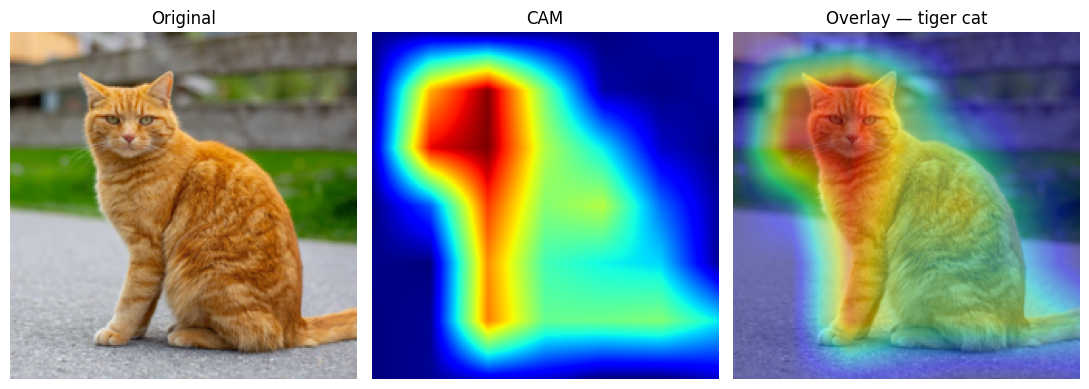

In [58]:
from PIL import Image as PILImage
import scipy.ndimage

top_class = int(top5_indices[0])

feat = np.array(result['last_hidden_state'][0], dtype=np.float32)           # (7, 7, 768)
w = np.array(m['classifier']['weight'][:, top_class], dtype=np.float32)     # (768,)

cam = np.maximum(feat @ w, 0)                       # (7, 7)  — ReLU
cam = (cam - cam.min()) / (cam.max() - cam.min())   # normalize to [0, 1]
cam = scipy.ndimage.zoom(cam, 224 / 7, order=1)     # (224, 224)

img_arr = np.array(PILImage.open(IMAGE_PATH).convert("RGB").resize((224, 224)))
fig, axes = plt.subplots(1, 3, figsize=(11, 4))

axes[0].imshow(img_arr);                         
axes[0].set_title("Original")
axes[1].imshow(cam, cmap="jet")      
axes[1].set_title("CAM")
axes[2].imshow(img_arr)
axes[2].imshow(cam, cmap="jet", alpha=0.45)
axes[2].set_title(f"Overlay — {index_to_label[str(top_class)]}")

for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


### GRN Channel Competition

GRN suppresses redundant channels by comparing each channel's spatial energy (L2 norm over H×W) against the mean. Channels with above-average energy get amplified; weak ones get suppressed. Plotting the sorted channel norms shows how "spread out" the competition is — a flat line would mean feature collapse; a steep curve means healthy competition.


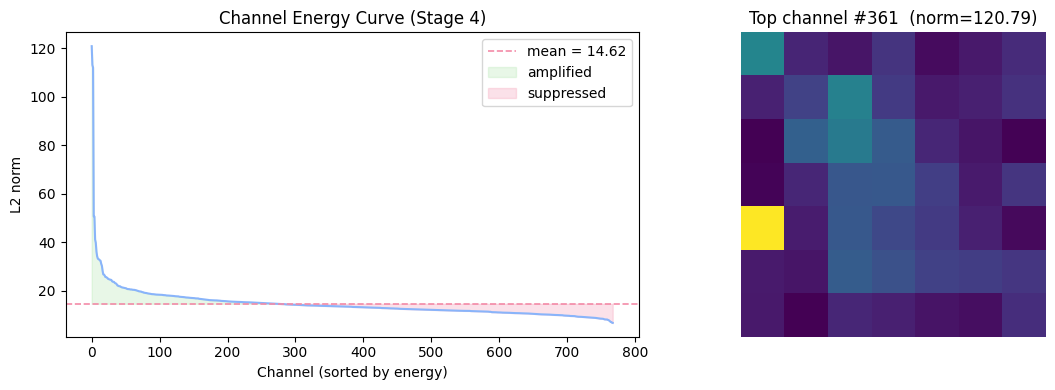

Amplified (above mean): 272 / 768 channels
Suppressed (below mean): 496 / 768 channels


In [59]:
feat = np.array(result['last_hidden_state'][0], dtype=np.float32)

channel_norms = np.linalg.norm(feat.reshape(-1, feat.shape[-1]), axis=0)
sorted_norms  = np.sort(channel_norms)[::-1]
mean_norm     = channel_norms.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sorted_norms, color='#89b4fa', linewidth=1.5)
axes[0].axhline(mean_norm, color='#f38ba8', linewidth=1.2, linestyle='--', label=f'mean = {mean_norm:.2f}')
axes[0].fill_between(range(len(sorted_norms)), mean_norm, sorted_norms,
                     where=sorted_norms >= mean_norm, alpha=0.25, color='#a6e3a1', label='amplified')
axes[0].fill_between(range(len(sorted_norms)), mean_norm, sorted_norms,
                     where=sorted_norms < mean_norm,  alpha=0.25, color='#f38ba8', label='suppressed')
axes[0].set_xlabel('Channel (sorted by energy)'); axes[0].set_ylabel('L2 norm')
axes[0].set_title('Channel Energy Curve (Stage 4)'); axes[0].legend()

top_ch    = np.argmax(channel_norms)
bot_ch    = np.argmin(channel_norms)
vmin, vmax = feat[..., top_ch].min(), feat[..., top_ch].max()

axes[1].imshow(feat[..., top_ch], cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Top channel #{top_ch}  (norm={channel_norms[top_ch]:.2f})')
axes[1].axis('off')

plt.tight_layout(); plt.show()

print(f"Amplified (above mean): {(channel_norms > mean_norm).sum()} / {len(channel_norms)} channels")
print(f"Suppressed (below mean): {(channel_norms <= mean_norm).sum()} / {len(channel_norms)} channels")
